In [12]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
path = str(Path.cwd().parent)
print(path)
sys.path.insert(1, path)

import numpy as np
import pandas as pd
import skforecast

print(skforecast.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/joaquin/Documents/GitHub/skforecast
0.22.0


## tabicl-forecasting

## Overview

[TabICLForecaster](https://github.com/soda-inria/tabicl/blob/main/src/tabicl/forecast/forecaster.py) is a **zero-shot** time series forecasting pipeline built on top of **TabICLv2**, a tabular foundation model.

Key characteristics:
- **No training required**: uses in-context learning — the pre-trained model generalises to new series without fine-tuning.
- **Single and multi-series support**: handles univariate or multiple related time series through an optional `item_id` column.
- **Probabilistic forecasts**: returns point predictions plus any requested quantiles (default `[0.1, …, 0.9]`).
- **Known future covariates**: accepts exogenous variables that are available at forecast time via `future_df`.

### Installation

```bash
pip install tabicl[forecast]
```

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from tabicl import TabICLForecaster
from tabicl.forecast import plot_forecast

from skforecast.datasets import fetch_dataset

## 1. Single-Series Forecasting

The simplest use case: a single time series with no covariates.  
`predict_df` is the recommended user-facing API — it accepts standard pandas DataFrames and requires:

| Column | Type | Description |
|---|---|---|
| `timestamp` | datetime | One row per observation |
| `target` | numeric | Values to forecast from |
| `item_id` | any (optional) | Series identifier; omit for single series |

Use `prediction_length` to specify how many steps to predict when no future covariates are needed.

In [14]:
# Load h2o dataset: monthly water consumption, 204 observations
# ─────────────────────────────────────────────────────────────────────────────
# fetch_dataset returns a single-column DataFrame; squeeze() converts it to a Series
data = fetch_dataset("h2o", verbose=False).squeeze()

# Build a flat DataFrame with the columns TabICLForecaster expects
context_df = pd.DataFrame({
    "timestamp": data.index,
    "target":    data.values,
    "item_id":   "h2o",        # explicit item_id makes plotting easier
})

# Train / test split — hold out the last 12 months
prediction_length = 12
context_df_train = context_df.iloc[:-prediction_length].copy()
test_df           = context_df.iloc[-prediction_length:].copy()

print(f"Training rows : {len(context_df_train)}")
print(f"Test rows     : {len(test_df)}")
context_df_train.tail(3)

Training rows : 192
Test rows     : 12


,timestamp,target,item_id
189,2007-04-01,0.561760,h2o
190,2007-05-01,0.745258,h2o
191,2007-06-01,0.837934,h2o


In [15]:
# Instantiate TabICLForecaster
# ─────────────────────────────────────────────────────────────────────────────
# max_context_length: maximum number of historical timesteps fed to the model.
# point_estimate:     "mean" (default) or "median" for the point forecast.
# tabicl_config:      dict passed to TabICLRegressor (e.g. n_estimators, device).
forecaster = TabICLForecaster(
    max_context_length=4096,
    point_estimate="mean",
)

# Generate forecasts for the next 12 months
# ─────────────────────────────────────────────────────────────────────────────
# predict_df returns a DataFrame indexed by (item_id, timestamp) with columns:
#   - "target" : point forecast
#   - 0.1, 0.2, …, 0.9 : predictive quantiles
pred_df = forecaster.predict_df(
    context_df=context_df_train,
    prediction_length=prediction_length,
    quantiles=[0.1, 0.5, 0.9],       # request only 3 quantiles to keep output tidy
)

pred_df

Predicting time series: 100%|██████████| 1/1 [00:05<00:00,  5.09s/it]


target       0.1       0.5       0.9
item_id timestamp                                         
h2o     2007-07-01  0.967242  0.884823  0.965960  1.051343
        2007-08-01  1.024035  0.937892  1.022900  1.112273
        2007-09-01  1.077974  0.987116  1.075515  1.173191
        2007-10-01  1.154888  1.054683  1.154563  1.256584
        2007-11-01  1.148384  1.049826  1.146833  1.248435
        2007-12-01  1.188938  1.089455  1.186992  1.290390
        2008-01-01  1.221926  1.099518  1.223850  1.340998
        2008-02-01  0.589433  0.500191  0.585568  0.683615
        2008-03-01  0.638479  0.547397  0.636652  0.733036
        2008-04-01  0.620734  0.519946  0.622012  0.723688
        2008-05-01  0.724840  0.622593  0.724223  0.829071
        2008-06-01  0.809599  0.701334  0.807970  0.919961

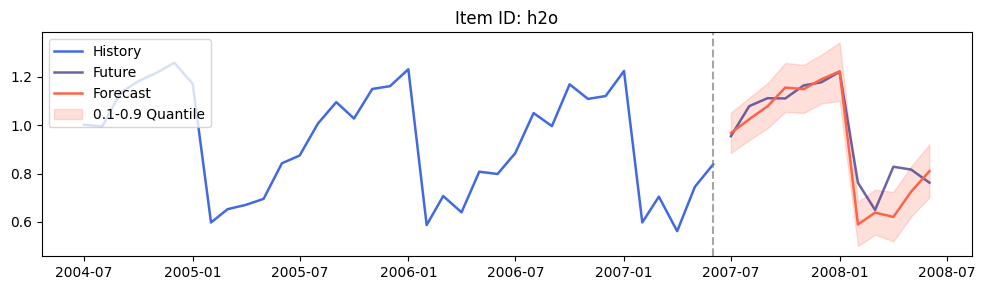

In [16]:
# Visualise using tabicl's built-in plot_forecast helper
# ─────────────────────────────────────────────────────────────────────────────
# context_length: how many historical steps to display (not the full training set)
fig, axes = plot_forecast(
    context_df=context_df_train,
    pred_df=pred_df,
    test_df=test_df,
    context_length=36,        # show the last 3 years of context
    show_quantiles=True,
)

## 2. Probabilistic Forecasting

`pred_df` contains one column per requested quantile alongside the `"target"` point forecast.  
The example below manually plots an 80 % prediction interval (quantiles 0.1 – 0.9) together with the actual test values.

Predicting time series: 100%|██████████| 1/1 [00:03<00:00,  3.81s/it]


pred_df columns: ['target', 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


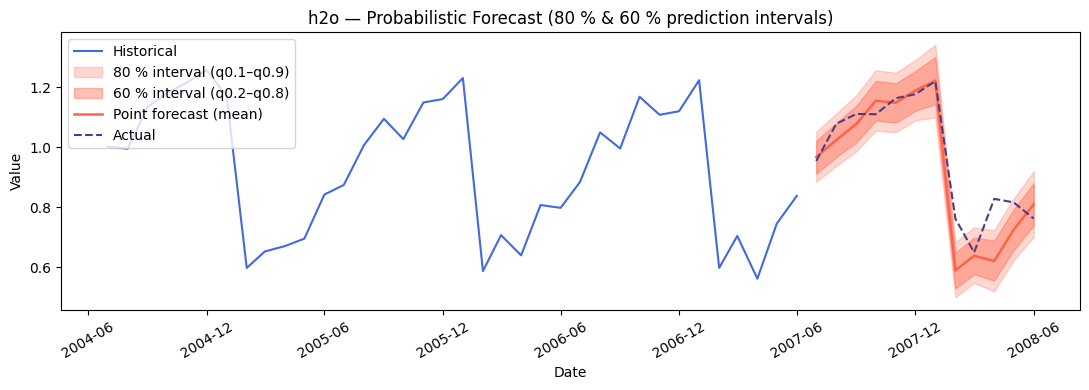

In [17]:
# Re-forecast with the default quantile set for a richer interval
# ─────────────────────────────────────────────────────────────────────────────
pred_df_full = forecaster.predict_df(
    context_df=context_df_train,
    prediction_length=prediction_length,
    # quantiles=None → defaults to [0.1, 0.2, ..., 0.9]
)
print("pred_df columns:", pred_df_full.columns.tolist())

# Extract predictions for the single series (item_id = "h2o")
preds      = pred_df_full.xs("h2o", level="item_id")
timestamps = preds.index

# Test ground truth
actual = test_df.set_index("timestamp")["target"]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))

# Historical context (last 36 months)
context_plot = context_df_train.set_index("timestamp").iloc[-36:]
ax.plot(context_plot.index, context_plot["target"],
        color="royalblue", linewidth=1.5, label="Historical")

# 80 % prediction interval (quantiles 0.1 – 0.9)
ax.fill_between(timestamps, preds[0.1], preds[0.9],
                alpha=0.25, color="tomato", label="80 % interval (q0.1–q0.9)")

# 60 % prediction interval (quantiles 0.2 – 0.8) — inner band
ax.fill_between(timestamps, preds[0.2], preds[0.8],
                alpha=0.40, color="tomato", label="60 % interval (q0.2–q0.8)")

# Point forecast
ax.plot(timestamps, preds["target"],
        color="tomato", linewidth=1.8, label="Point forecast (mean)")

# Actual test values
ax.plot(actual.index, actual.values,
        color="darkslateblue", linewidth=1.5, linestyle="--", label="Actual")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30)
ax.set_title("h2o — Probabilistic Forecast (80 % & 60 % prediction intervals)")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 3. Multi-Series Forecasting

When `context_df` contains an `item_id` column, `TabICLForecaster` treats each unique value as an independent time series and returns a prediction for each one in a single call.

The `items_sales` dataset provides daily sales for three items in wide format — we reshape it to the long format required by `predict_df`.

In [18]:
# Load items_sales dataset: daily sales for 3 items, wide format
# ─────────────────────────────────────────────────────────────────────────────
data_ms = fetch_dataset("items_sales", verbose=False)
print(f"Shape   : {data_ms.shape}")
print(f"Columns : {data_ms.columns.tolist()}")
data_ms.head(3)

Shape   : (1097, 3)
Columns : ['item_1', 'item_2', 'item_3']


,item_1,item_2,item_3
date,,,
2012-01-01,8.253175,21.047727,19.429739
2012-01-02,22.777826,26.578125,28.009863
2012-01-03,27.549099,31.751042,32.078922


In [19]:
# Reshape wide → long: one row per (item_id, timestamp)
# ─────────────────────────────────────────────────────────────────────────────
index_col = data_ms.index.name  # "date" in items_sales

context_df_ms = (
    data_ms
    .reset_index()
    .melt(id_vars=[index_col], var_name="item_id", value_name="target")
    .rename(columns={index_col: "timestamp"})
    .sort_values(["item_id", "timestamp"])
    .reset_index(drop=True)
)
print(f"Items   : {context_df_ms['item_id'].unique().tolist()}")
print(f"Rows    : {len(context_df_ms)}")
context_df_ms.head(6)

Items   : ['item_1', 'item_2', 'item_3']
Rows    : 3291


,timestamp,item_id,target
0,2012-01-01,item_1,8.253175
1,2012-01-02,item_1,22.777826
2,2012-01-03,item_1,27.549099
3,2012-01-04,item_1,25.895533
4,2012-01-05,item_1,21.379238
5,2012-01-06,item_1,21.106643


In [20]:
# Train / test split — hold out the last 30 days per item
# ─────────────────────────────────────────────────────────────────────────────
prediction_length_ms = 30

context_df_ms_train = (
    context_df_ms
    .groupby("item_id", group_keys=False)
    .apply(lambda g: g.iloc[:-prediction_length_ms])
    .reset_index(drop=True)
)

test_df_ms = (
    context_df_ms
    .groupby("item_id", group_keys=False)
    .apply(lambda g: g.iloc[-prediction_length_ms:])
    .reset_index(drop=True)
)

print(f"Training rows : {len(context_df_ms_train)}  "
      f"({len(context_df_ms_train) // context_df_ms['item_id'].nunique()} per item)")
print(f"Test rows     : {len(test_df_ms)}  "
      f"({len(test_df_ms) // context_df_ms['item_id'].nunique()} per item)")

Training rows : 3201  (1067 per item)
Test rows     : 90  (30 per item)


/tmp/ipykernel_7899/3904649654.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.iloc[:-prediction_length_ms])
/tmp/ipykernel_7899/3904649654.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.iloc[-prediction_length_ms:])


In [21]:
# Forecast all 3 items in a single call
# ─────────────────────────────────────────────────────────────────────────────
# TabICLForecaster detects the item_id column and produces predictions for
# every item present in context_df.
pred_df_ms = forecaster.predict_df(
    context_df=context_df_ms_train,
    prediction_length=prediction_length_ms,
    quantiles=[0.1, 0.9],
)

print("pred_df MultiIndex levels:", pred_df_ms.index.names)
print("Items in pred_df        :", pred_df_ms.index.get_level_values("item_id").unique().tolist())
pred_df_ms

Predicting time series: 100%|██████████| 3/3 [00:00<00:00, 152.29it/s]


pred_df MultiIndex levels: ['item_id', 'timestamp']
Items in pred_df        : ['item_1', 'item_2', 'item_3']


target        0.1        0.9
item_id timestamp                                  
item_1  2014-12-03  23.433121  20.917259  26.402746
        2014-12-04  23.406021  20.776894  26.564302
        2014-12-05  23.725273  21.049065  26.982395
        2014-12-06  22.616367  19.984034  25.713787
        2014-12-07  20.522413  18.061939  23.333643
...                       ...        ...        ...
item_3  2014-12-28  20.732985  15.384142  27.137390
        2014-12-29  20.739544  15.393933  27.141279
        2014-12-30  20.721811  15.401261  27.086231
        2014-12-31  20.755562  15.426672  27.135870
        2015-01-01  20.717937  15.423326  27.120682

[90 rows x 3 columns]

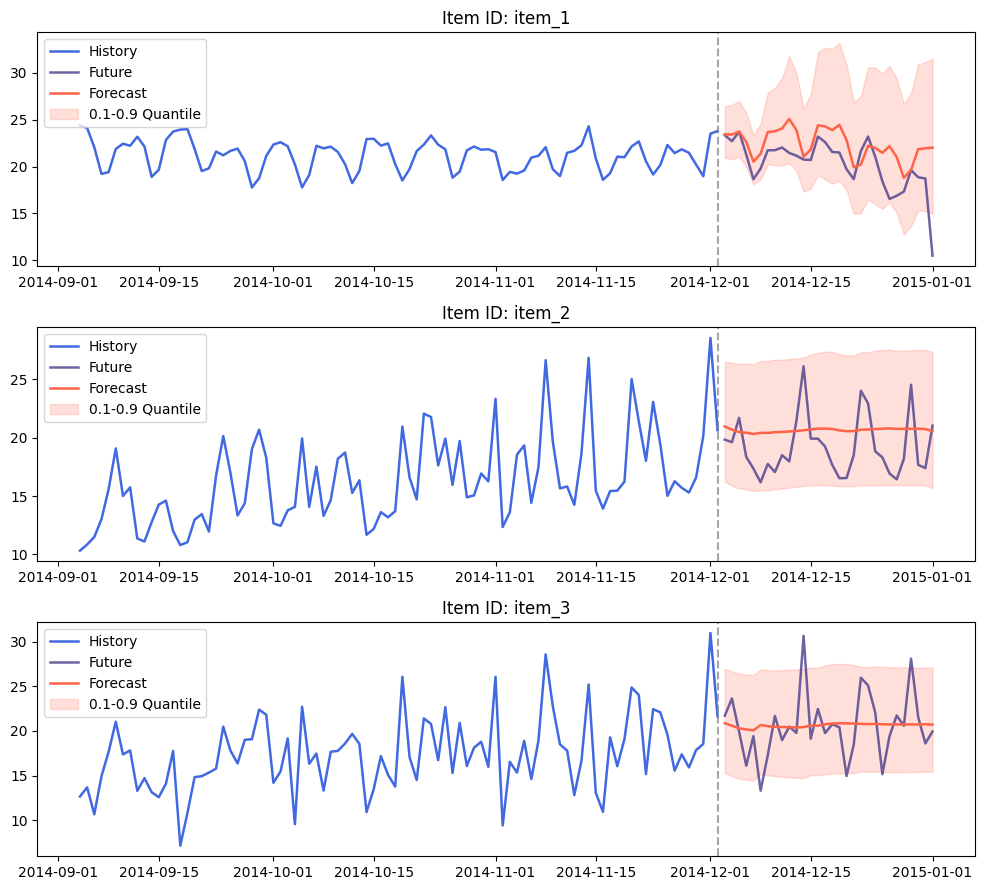

In [22]:
# Visualise all items
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plot_forecast(
    context_df=context_df_ms_train,
    pred_df=pred_df_ms,
    test_df=test_df_ms,
    context_length=90,         # display the last 90 days of context per item
    show_quantiles=True,
)

## 4. Known Future Covariates

When exogenous variables are available during the forecast horizon (e.g. calendar features, weather forecasts, promotions), pass them through `future_df` instead of `prediction_length`.

Rules for `future_df`:
- Must contain `timestamp` (and `item_id` if multi-series).
- Covariate columns must **match those in `context_df`**; only the intersection is used.
- The `target` column is optional; if present every value must be `NaN`.

The `h2o_exog` dataset provides a monthly target series plus two exogenous variables.

In [23]:
# Load h2o_exog dataset: monthly target + exogenous variables
# ─────────────────────────────────────────────────────────────────────────────
data_exog = fetch_dataset("h2o_exog", verbose=False)
print(f"Shape   : {data_exog.shape}")
print(f"Columns : {data_exog.columns.tolist()}")
data_exog.head(3)

Shape   : (195, 3)
Columns : ['y', 'exog_1', 'exog_2']


,y,exog_1,exog_2
fecha,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942


In [24]:
# Identify target and exogenous columns
# ─────────────────────────────────────────────────────────────────────────────
# h2o_exog: first column is the target ("y"); the rest are exogenous variables
target_col = data_exog.columns[0]                                   # "y"
exog_cols  = [c for c in data_exog.columns if c != target_col]      # exogenous

print(f"Target column    : {target_col}")
print(f"Exogenous columns: {exog_cols}")

# Train / test split — hold out last 12 months
prediction_length_exog = 12
train_exog = data_exog.iloc[:-prediction_length_exog]
test_exog  = data_exog.iloc[-prediction_length_exog:]

# ── context_df: historical target + historical covariate values ───────────────
context_df_exog = pd.DataFrame({
    "timestamp": train_exog.index,
    "target":    train_exog[target_col].values,
    "item_id":   "h2o_exog",
})
for col in exog_cols:
    context_df_exog[col] = train_exog[col].values

# ── future_df: future timestamps + KNOWN future covariate values ──────────────
# target is NaN — it is what we want to predict
future_df_exog = pd.DataFrame({
    "timestamp": test_exog.index,
    "item_id":   "h2o_exog",
    "target":    np.nan,           # unknown (will be predicted)
})
for col in exog_cols:
    future_df_exog[col] = test_exog[col].values  # known future values

print(f"\ncontext_df columns : {context_df_exog.columns.tolist()}")
print(f"future_df columns  : {future_df_exog.columns.tolist()}")
future_df_exog.head(3)

Target column    : y
Exogenous columns: ['exog_1', 'exog_2']

context_df columns : ['timestamp', 'target', 'item_id', 'exog_1', 'exog_2']
future_df columns  : ['timestamp', 'item_id', 'target', 'exog_1', 'exog_2']


,timestamp,item_id,target,exog_1,exog_2
0,2007-07-01,h2o_exog,NaN,1.402091,1.460699
1,2007-08-01,h2o_exog,NaN,1.393088,1.535463
2,2007-09-01,h2o_exog,NaN,1.393382,1.645307


In [25]:
# Forecast using future_df (covariates known at forecast time)
# ─────────────────────────────────────────────────────────────────────────────
# Pass future_df instead of prediction_length when you have known future
# covariate values.  TabICLForecaster intersects the covariate columns from
# context_df and future_df and incorporates them into the feature matrix.
pred_df_exog = forecaster.predict_df(
    context_df=context_df_exog,
    future_df=future_df_exog,   # ← future_df instead of prediction_length
    quantiles=[0.1, 0.9],
)

# Ground truth for comparison
actual_exog = test_exog[[target_col]].rename(columns={target_col: "actual"})

# Merge predictions with actuals for inspection
comparison = pred_df_exog.reset_index(level="item_id", drop=True).join(actual_exog)
comparison

Predicting time series: 100%|██████████| 1/1 [00:03<00:00,  3.89s/it]


,target,0.1,0.9,actual
timestamp,,,,
2007-07-01,0.943922,0.887789,1.001172,0.954144
2007-08-01,1.027050,0.968787,1.081536,1.078219
2007-09-01,1.093452,1.030140,1.153259,1.110982
2007-10-01,1.179389,1.113081,1.239506,1.109979
2007-11-01,1.181419,1.117437,1.237969,1.163534
2007-12-01,1.209615,1.142530,1.267045,1.176589
2008-01-01,1.209054,1.134945,1.272112,1.219941
2008-02-01,0.621113,0.556076,0.691372,0.761822
2008-03-01,0.691250,0.621419,0.760400,0.649435


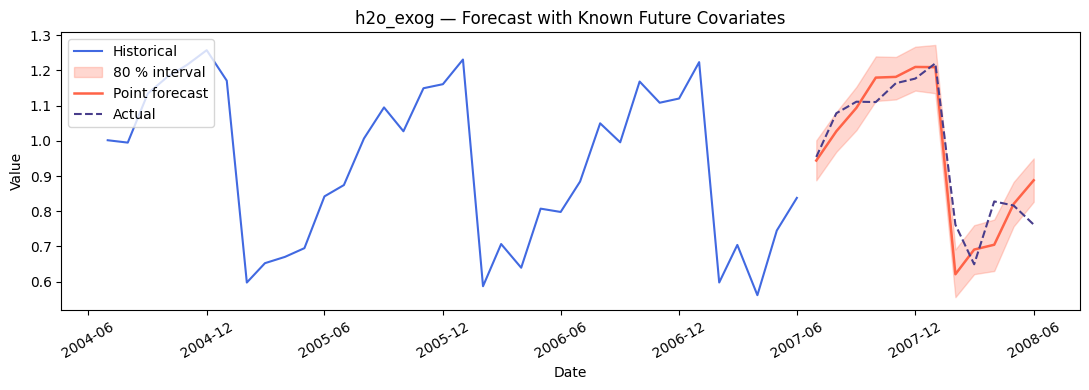

In [26]:
# Visualise forecast vs actuals with 80 % interval
# ─────────────────────────────────────────────────────────────────────────────
preds_exog = pred_df_exog.xs("h2o_exog", level="item_id")
context_plot_exog = context_df_exog.set_index("timestamp").iloc[-36:]

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(context_plot_exog.index, context_plot_exog["target"],
        color="royalblue", linewidth=1.5, label="Historical")

ax.fill_between(preds_exog.index, preds_exog[0.1], preds_exog[0.9],
                alpha=0.25, color="tomato", label="80 % interval")

ax.plot(preds_exog.index, preds_exog["target"],
        color="tomato", linewidth=1.8, label="Point forecast")

ax.plot(actual_exog.index, actual_exog["actual"],
        color="darkslateblue", linewidth=1.5, linestyle="--", label="Actual")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30)
ax.set_title("h2o_exog — Forecast with Known Future Covariates")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()